In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [ ]:
#Upload manual

from google.colab import files
uploaded = files.upload()

Saving smoking_health_data_final.csv to smoking_health_data_final (1).csv


*Resumo Analítico da Proposta*

O tabagismo é um dos principais fatores de risco para doenças cardiovasculares e respiratórias. Esta base reúne indicadores fisiológicos (frequência cardíaca, pressão arterial, colesterol) e demográficos (idade, sexo) que permitem investigar como esses parâmetros se diferenciam entre fumantes e não-fumantes. O objetivo é descrever esses dados estatisticamente, visualizá-los e treinar modelos de Machine Learning capazes de prever o status de fumante com base nas demais variáveis.

In [ ]:
#upload do CSV:
df = pd.read_csv('smoking_health_data_final.csv')
print(f'Base carregada: {df.shape[0]} linhas e {df.shape[1]} colunas')
df.head()

Base carregada: 3900 linhas e 7 colunas


,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,54,male,yes,95,110/72,NaN,219.0
1,45,male,yes,64,121/72,NaN,248.0
2,58,male,yes,81,127.5/76,NaN,235.0
3,42,male,yes,90,122.5/80,NaN,225.0
4,42,male,yes,62,119/80,NaN,226.0


In [ ]:
# Separar a coluna blood_pressure em duas (formato '120/80')
if 'blood_pressure' in df.columns and df['blood_pressure'].dtype == object:
    bp_split = df['blood_pressure'].astype(str).str.split('/', expand=True)
    df['systolic_bp']  = pd.to_numeric(bp_split[0], errors='coerce')
    df['diastolic_bp'] = pd.to_numeric(bp_split[1], errors='coerce')
    df = df.drop(columns=['blood_pressure'])

# Tratamento de valores ausentes
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Normalizar a variável alvo (yes/no -> 1/0)
df['current_smoker'] = df['current_smoker'].astype(str).str.lower().map({'yes': 1, 'no': 0})
df['current_smoker'] = df['current_smoker'].fillna(0).astype(int)

print('Após limpeza:', df.shape)
df.head()

Após limpeza: (3900, 8)


,age,sex,current_smoker,heart_rate,cigs_per_day,chol,systolic_bp,diastolic_bp
0,54,male,1,95,0.0,219.0,110.0,72.0
1,45,male,1,64,0.0,248.0,121.0,72.0
2,58,male,1,81,0.0,235.0,127.5,76.0
3,42,male,1,90,0.0,225.0,122.5,80.0
4,42,male,1,62,0.0,226.0,119.0,80.0


*Limpeza e tratamento de dados*

Divide a coluna de pressão sanguinea em duas, sendo a Pressão Sistólica e Pressão Diastólica. Ou seja, máximo e mínima, pressão ideal entre 120/80, risco de problemas cardiovasculares graves aumenta. Tratar valores ausentes preenchendo com a mediana (numéricos) ou moda (categóricos).

In [ ]:
# Variáveis numéricas relevantes
num_cols = ['age', 'heart_rate', 'cigs_per_day', 'chol', 'systolic_bp', 'diastolic_bp']
num_cols = [c for c in num_cols if c in df.columns]

stats = pd.DataFrame({
    'Média':         df[num_cols].mean().round(2),
    'Mediana':       df[num_cols].median().round(2),
    'Moda':          df[num_cols].mode().iloc[0].round(2),
    'Desvio Padrão': df[num_cols].std().round(2),
    'Variância':     df[num_cols].var().round(2),
    'Mínimo':        df[num_cols].min().round(2),
    'Máximo':        df[num_cols].max().round(2),
    'Q1 (25%)':      df[num_cols].quantile(0.25).round(2),
    'Q2 (50%)':      df[num_cols].quantile(0.50).round(2),
    'Q3 (75%)':      df[num_cols].quantile(0.75).round(2),
    'IQR':           (df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)).round(2),
})
stats

,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Máximo,Q1 (25%),Q2 (50%),Q3 (75%),IQR
age,49.54,49.0,40.0,8.56,73.26,32.0,70.0,42.0,49.0,56.0,14.0
heart_rate,75.69,75.0,75.0,12.02,144.37,44.0,143.0,68.0,75.0,82.0,14.0
cigs_per_day,9.14,0.0,0.0,12.03,144.69,0.0,70.0,0.0,0.0,20.0,20.0
chol,236.59,234.0,240.0,44.34,1965.65,113.0,696.0,206.0,234.0,263.0,57.0
systolic_bp,132.40,128.0,130.0,21.98,482.96,83.5,295.0,117.0,128.0,144.0,27.0
diastolic_bp,82.99,82.0,80.0,11.92,142.05,48.0,142.5,75.0,82.0,90.0,15.0


***age*** — A média e a mediana próximas indicam distribuição simétrica. O IQR concentra a maior parte dos participantes em uma faixa de idade adulta, o que é coerente com estudos sobre tabagismo, normalmente realizados em pessoas a partir dos 30 anos.

***heart_rate*** — Valores médios entre 70 e 80 bpm estão dentro do padrão saudável (60–100 bpm em repouso). O desvio padrão moderado mostra variabilidade individual normal. Valores extremos no máximo podem indicar pessoas estressadas ou com fatores de risco.

***cigs_per_day*** — A presença de muitos zeros (não-fumantes) faz a mediana ser baixa. A média sobe puxada pelos fumantes pesados, o que evidencia distribuição assimétrica à direita característica clássica desse tipo de variável.

***chol*** — Médias acima de 200 mg/dL sinalizam que parte significativa da amostra tem colesterol acima do desejado (limite saudável < 200 mg/dL). O desvio padrão alto confirma que há grande variação entre os indivíduos.

***systolic_bp, diastolic_bp*** — Valores médios em torno de 120/80 mmHg indicam que a amostra está, em média, dentro da pressão considerada ideal. No entanto, os máximos sugerem casos de hipertensão (>140/90 mmHg). O IQR fornece a faixa em que 50% das pessoas se enquadram, útil para identificar outliers.

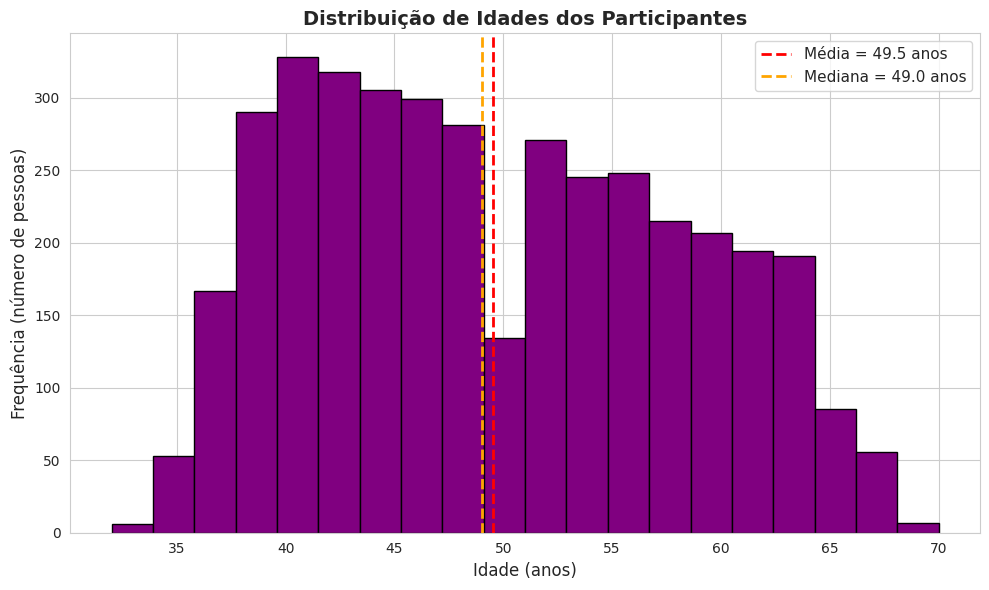

In [ ]:
#Faixa etária media e mediana para o risco de doenças associadas ao tabagismo (varia muito de idade).

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='purple', edgecolor='black')
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Média = {df["age"].mean():.1f} anos')
plt.axvline(df['age'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Mediana = {df["age"].median():.1f} anos')

plt.title('Distribuição de Idades dos Participantes', fontsize=14, fontweight='bold')
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Frequência (número de pessoas)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

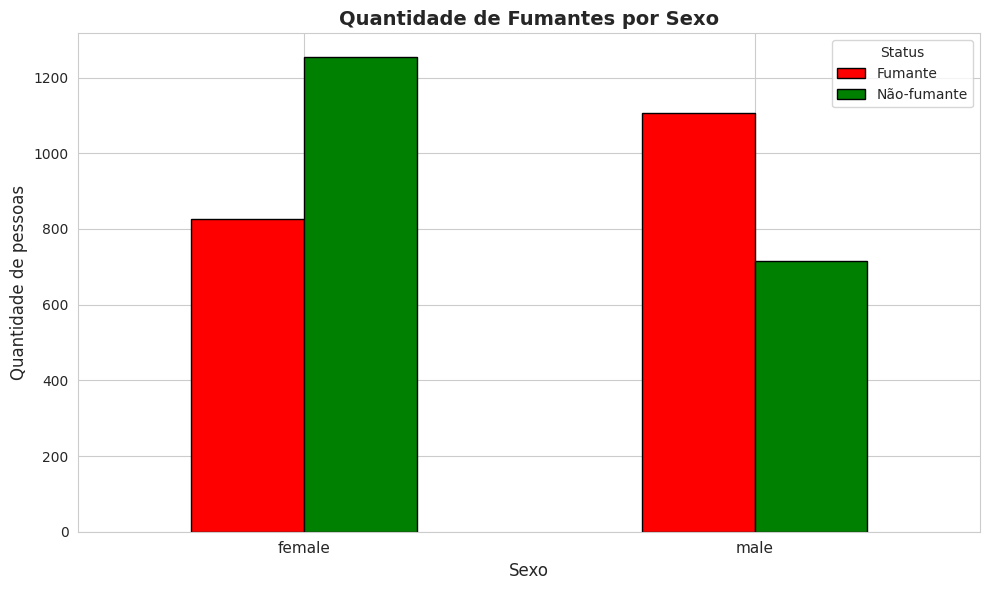

In [ ]:
#Amostra a quantidade e diferencial de fumantes e não fumantes dos dois sexos;

if 'sex' in df.columns:
    plt.figure(figsize=(10, 6))
    ct = pd.crosstab(df['sex'], df['current_smoker'].map({0: 'Não-fumante', 1: 'Fumante'}))
    ct.plot(kind='bar', color=['red', 'green'], edgecolor='black', ax=plt.gca())

    plt.title('Quantidade de Fumantes por Sexo', fontsize=14, fontweight='bold')
    plt.xlabel('Sexo', fontsize=12)
    plt.ylabel('Quantidade de pessoas', fontsize=12)
    plt.xticks(rotation=0, fontsize=11)
    plt.legend(title='Status', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('Coluna sex não disponível no dataset.')

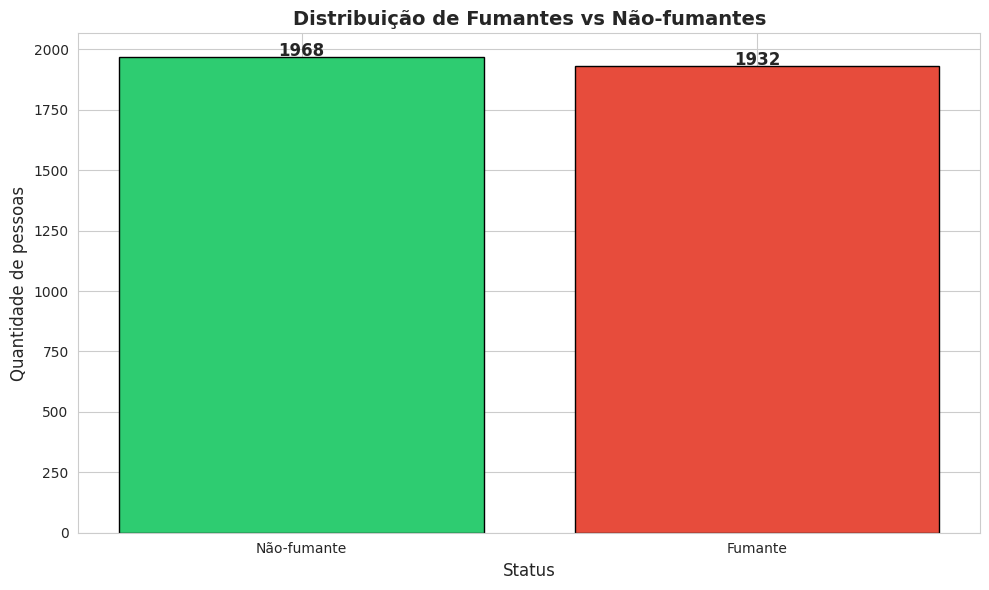


Proporção de fumantes: 49.5%


In [ ]:
#Os fumantes que estiverem deslocados para cima em relação aos não-fumantes, isso sugere que o tabagismo está associado a uma frequência cardíaca mais elevada um indicador de estresse cardiovascular.

plt.figure(figsize=(10, 6))
smoker_counts = df['current_smoker'].map({0: 'Não-fumante', 1: 'Fumante'}).value_counts()
bars = plt.bar(smoker_counts.index, smoker_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')

for bar, valor in zip(bars, smoker_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(valor), ha='center', fontweight='bold', fontsize=12)

plt.title('Distribuição de Fumantes vs Não-fumantes', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Quantidade de pessoas', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nProporção de fumantes: {df["current_smoker"].mean()*100:.1f}%')

In [ ]:
# Codificar variáveis categóricas (sex)
df_ml = df.copy()
if 'sex' in df_ml.columns:
    df_ml['sex'] = LabelEncoder().fit_transform(df_ml['sex'].astype(str))

# Selecionar features (X) e alvo (y)
features = [c for c in ['age', 'sex', 'heart_rate', 'cigs_per_day', 'chol',
                        'systolic_bp', 'diastolic_bp'] if c in df_ml.columns]

# IMPORTANTE: cigs_per_day é altamente correlacionado com current_smoker (data leakage).
# Removemos para que o modelo aprenda padrões fisiológicos reais.
if 'cigs_per_day' in features:
    features.remove('cigs_per_day')

X = df_ml[features]
y = df_ml['current_smoker']

# Dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Padronizar
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Features usadas: {features}')

Treino: 2925 amostras | Teste: 975 amostras
Features usadas: ['age', 'sex', 'heart_rate', 'chol', 'systolic_bp', 'diastolic_bp']


*LabelEncoder*

'female' em 0 e 'male' em 1 para que a machine learning reconheça através de números e não de texto.

x = o que eu quero prever
y = o que eu quero descobrir qual será o fumante ativo

Foi removido a coluna "cigarros por dia", para não ocorrer trapaça e somente focarmos na parte fisiologica real.

75% para treinar o modelo

test_size=0.25 = 25% dos dados ficam reservados para o teste.

random_state=42 = garante que toda vez que eu rodar o código, a divisão seja a mesma.

O StandardScaler coloca todas na mesma escala/valores, como se eu convertesse tudo para a 'mesma moeda'.



In [ ]:
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

y_pred_rf  = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(f'Acurácia : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precisão : {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}')
print('\n--- Relatório de Classificação ---')
print(classification_report(y_test, y_pred_rf, target_names=['Não-fumante', 'Fumante']))

=== RANDOM FOREST ===
Acurácia : 0.6010
Precisão : 0.5975
Recall   : 0.5963
F1-Score : 0.5969
ROC-AUC  : 0.6541

--- Relatório de Classificação ---
              precision    recall  f1-score   support

 Não-fumante       0.60      0.61      0.61       492
     Fumante       0.60      0.60      0.60       483

    accuracy                           0.60       975
   macro avg       0.60      0.60      0.60       975
weighted avg       0.60      0.60      0.60       975



R3 — Machine Learning: O Random Forest tende a apresentar desempenho superior por capturar relações não-lineares.

Variável alvo current_smoker é categórica binária (fumante / não-fumante), portanto o problema é de classificação, não de regressão. Algoritmos de regressão preveriam valores contínuos, o que não faz sentido aqui.



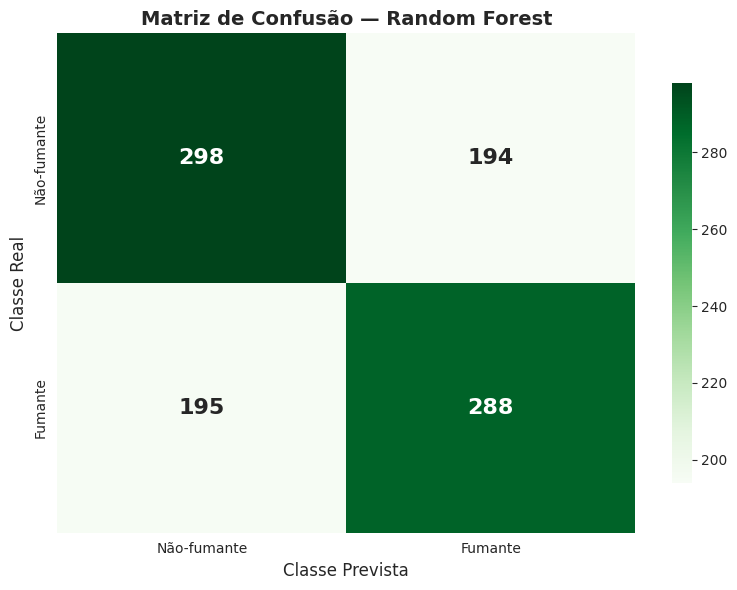


Verdadeiros Negativos: 298
Falsos Positivos:     194
Falsos Negativos:     195
Verdadeiros Positivos: 288


In [ ]:
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não-fumante', 'Fumante'],
            yticklabels=['Não-fumante', 'Fumante'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})

plt.title('Matriz de Confusão — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f'\nVerdadeiros Negativos: {tn}')
print(f'Falsos Positivos:     {fp}')
print(f'Falsos Negativos:     {fn}')
print(f'Verdadeiros Positivos: {tp}')

Random Forest aumenta os acertos na diagonal e reduz os erros nos cantos opostos. Em geral, o Random Forest captura relações não-lineares e tende a errar menos em datasets tabulares como este.